<a href="https://colab.research.google.com/github/Yelmi95/IA_SIS420/blob/main/Lab05_Pythor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 1 - Prediccion de Productividad con Red Neuronal (PyTorch)**
**Nombre:** Yulitza Alcibia Miranda

**Grupo:** 2

**Dataset:** Student Productivity & Digital Distraction Dataset

**Link:** https://drive.google.com/file/d/1PHOn_1-26Kj2jzM3TumXUhsu4ZLpxeZV/view?usp=sharing

## Descripcion del Dataset
El dataset contiene informacion de **20,000 estudiantes** con variables de habitos academicos,
uso digital y rendimiento.

## Variable objetivo
Se predice **`productivity_score`** (0-100), que representa el nivel general de productividad.

## Estructura del laboratorio
1. Carga y exploracion de datos
2. Normalizacion de variables
3. Preparacion de tensores y `DataLoader`
4. Definicion y entrenamiento de una red neuronal
5. Evaluacion y prediccion en un nuevo estudiante



In [ ]:
# Librería para manejo de directorios y rutas
import os

# Librería para computación vectorial y científica
import numpy as np

# Librería para graficar
from matplotlib import pyplot

# Permite mostrar las gráficas dentro del cuadernillo
%matplotlib inline
import torch
import pandas as pd

# Paso 1 — Cargar el dataset
Se carga el archivo `student_productivity_distraction_dataset_20000.csv` desde
**Google Drive** utilizando `numpy.loadtxt`. Se omiten las columnas `student_id`
y `gender` por ser un identificador y una variable de texto respectivamente,
trabajando con **15 variables numéricas** como predictoras y `productivity_score`
como variable objetivo, obteniendo un total de **20,000 ejemplos** de entrenamiento.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

df = pd.read_csv('/content/drive/MyDrive/IA_sis420/LABORATORIOS/DATASET/student_productivity_distraction_dataset_20000.csv')

# 2. Convertir gender (AQUÍ VA)
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df = df.dropna()
# 3. Seleccionar variables
X = df[[
    'age',
    'study_hours_per_day',
    'sleep_hours',
    'phone_usage_hours',
    'social_media_hours',
    'youtube_hours',
    'gaming_hours',
    'breaks_per_day',
    'coffee_intake_mg',
    'exercise_minutes',
    'assignments_completed',
    'attendance_percentage',
    'stress_level',
    'focus_score',
    'gender'
]]

# 4. Variable objetivo
y = df['productivity_score']

X = X.values
y = y.values

print(f"Ejemplos: {X.shape[0]}")
print(f"Características: {X.shape[1]}")
print("\nPrimeras 5 filas:")
print(X[:5])


Ejemplos: 19222
Características: 15

Primeras 5 filas:
[[2.300e+01 4.350e+00 3.630e+00 3.380e+00 2.730e+00 1.830e+00 5.260e+00
  6.000e+00 3.470e+02 1.110e+02 2.000e+00 5.721e+01 1.000e+01 5.700e+01
  0.000e+00]
 [2.000e+01 6.140e+00 6.580e+00 5.480e+00 1.510e+00 3.130e+00 1.730e+00
  1.300e+01 4.030e+02 2.800e+01 1.000e+01 9.127e+01 1.000e+01 4.900e+01
  1.000e+00]
 [2.900e+01 4.980e+00 3.260e+00 4.830e+00 3.630e+00 1.800e-01 4.710e+00
  1.000e+00 4.190e+02 1.020e+02 8.000e+00 6.314e+01 2.000e+00 3.800e+01
  0.000e+00]
 [2.700e+01 3.190e+00 4.580e+00 1.006e+01 3.950e+00 5.750e+00 2.520e+00
  9.000e+00 1.780e+02 2.800e+01 1.800e+01 4.051e+01 6.000e+00 5.000e+01
  0.000e+00]
 [2.400e+01 7.670e+00 6.210e+00 3.020e+00 1.590e+00 5.460e+00 5.650e+00
  8.000e+00 4.360e+02 1.050e+02 7.000e+00 4.553e+01 6.000e+00 4.100e+01
  1.000e+00]]


---

## Paso 2: División y Normalización

**Orden correcto:** Primero se divide el dataset en conjuntos de entrenamiento (80 %) y
prueba (20 %), y **luego** se normaliza. Los parámetros `mu` y `sigma` se calculan
**únicamente con los datos de entrenamiento** y después se aplican al conjunto de prueba.
Esto evita el *data leakage* (filtrado de información del test hacia el train).


In [ ]:
def featureNormalize(X):

    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma


In [ ]:
# PASO 1: Dividir en train/test ANTES de normalizar
total      = len(X)
train_size = int(total * 0.8)   # 16,000 ejemplos

X_train_raw = X[:train_size]
X_test_raw  = X[train_size:]
y_train_raw = y[:train_size]
y_test_raw  = y[train_size:]

print(f"Ejemplos de entrenamiento: {X_train_raw.shape[0]}")
print(f"Ejemplos de prueba:        {X_test_raw.shape[0]}")


Ejemplos de entrenamiento: 15377
Ejemplos de prueba:        3845


In [ ]:

X_train_norm, mu, sigma = featureNormalize(X_train_raw)
X_test_norm             = (X_test_raw - mu) / sigma

print('Media calculada (train):          ', mu)
print('Desviacion estandar calculada (train):', sigma)
print('Primeras filas de X_train_norm:')
print(X_train_norm[:3])


Media calculada (train):           [ 23.02321649   5.25635495   6.53416986   6.26788515   4.01302465
   2.98735579   2.98189894   7.54633544 248.58320869  59.66313325
   9.50549522  69.82428952   5.46959745  64.33699681   0.49892697]
Desviacion estandar calculada (train): [  3.7662631    2.74210888   2.02431032   3.30879824   2.30258618
   1.73343943   1.7328917    4.02222185 143.64208946  34.71780441
   5.80218324  17.34919775   2.87125987  20.1569082    0.49999885]
Primeras filas de X_train_norm:
[[-0.00616433 -0.33053208 -1.43464657 -0.87278974 -0.55721026 -0.6676644
   1.31462403 -0.38444807  0.68515288  1.4786899  -1.29356397 -0.72708201
   1.57784483 -0.36399416 -0.99785624]
 [-0.80270985  0.32225017  0.02263988 -0.23811822 -1.08704928  0.0822897
  -0.72243346  1.35588358  1.07501076 -0.91201428  0.08522736  1.23612116
   1.57784483 -0.76088042  1.00214837]
 [ 1.58692671 -0.1007819  -1.61742487 -0.43456417 -0.16634541 -1.61952921
   0.99723547 -1.62754211  1.18639872  1.21945692 

## PASO 3: Convertir a tensores PyTorch

In [ ]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'

X_train_tensor = torch.from_numpy(X_train_norm).float().to(device)
y_train_tensor = torch.from_numpy(y_train_raw).float().to(device)

X_test_tensor  = torch.from_numpy(X_test_norm).float().to(device)
y_test_tensor  = torch.from_numpy(y_test_raw).float().to(device)

print(f'Train: {X_train_tensor.shape}   Test: {X_test_tensor.shape}')


Train: torch.Size([15377, 15])   Test: torch.Size([3845, 15])


### PASO 4: Crear Dataset personalizado

In [ ]:


class StudentDataset(torch.utils.data.Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]


train_dataset = StudentDataset(X_train_tensor, y_train_tensor)
test_dataset  = StudentDataset(X_test_tensor,  y_test_tensor)

print(f'Ejemplos de entrenamiento: {len(train_dataset)}')
print(f'Ejemplos de evaluacion:    {len(test_dataset)}')


Ejemplos de entrenamiento: 15377
Ejemplos de evaluacion:    3845


# PASO 5: Crear DataLoader

In [ ]:

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=100, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,  batch_size=100, shuffle=False
)

print(f'Batches de entrenamiento: {len(train_loader)}')
print(f'Batches de evaluacion:    {len(test_loader)}')


Batches de entrenamiento: 154
Batches de evaluacion:    39


## PASO 6: DEFINICION DE LA RED NEURAL SECUENCIAL

In [ ]:
D_in  = X_train_tensor.shape[1]
H     = 128
D_out = 1

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
).to(device)

print(model)
print(f'\nParametros del modelo: {sum(p.numel() for p in model.parameters())}')


Sequential(
  (0): Linear(in_features=15, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=1, bias=True)
)

Parametros del modelo: 2177


In [ ]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


### PASO 7: Entrenamiento
En cada `epoch` el modelo recorre todos los batches de entrenamiento,
calcula predicciones, mide el error con MSE y ajusta los pesos mediante
descenso por gradiente estocastico (SGD).
El orden correcto dentro del loop es: **zero_grad → forward → loss → backward → step**.
La curva de `train_losses` debe descender si el modelo esta aprendiendo.


In [ ]:

epochs    = 100
log_each  = 10
train_losses      = []
test_losses_epoch = []
best_loss = float('inf')   # ← NUEVO
PATH = '/content/drive/MyDrive/IA_sis420/LABORATORIOS/modelo_estudiantes.pt'

for e in range(1, epochs + 1):

    model.train()
    batch_losses = []
    for x_b, y_b in train_loader:
        optimizer.zero_grad()
        y_pred = model(x_b).squeeze()
        loss   = criterion(y_pred, y_b)
        batch_losses.append(loss.item())
        loss.backward()
        optimizer.step()

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        t_losses = []
        for x_b, y_b in test_loader:
            y_pred = model(x_b).squeeze()
            t_losses.append(criterion(y_pred, y_b).item())
        test_loss_e = np.mean(t_losses)
        test_losses_epoch.append(test_loss_e)

    # ← NUEVO: guardar solo si mejoró
    if test_loss_e < best_loss:
        best_loss = test_loss_e
        torch.save(model.state_dict(), PATH)
        print(f' Epoch {e}: guardado (Test Loss: {test_loss_e:.4f})')

    if not e % log_each:
        print(f'Epoch {e}/{epochs}  Train Loss: {train_loss:.4f}  Test Loss: {test_loss_e:.4f}')


 Epoch 1: guardado (Test Loss: 0.0570)
 Epoch 3: guardado (Test Loss: 0.0319)
 Epoch 4: guardado (Test Loss: 0.0098)
 Epoch 5: guardado (Test Loss: 0.0069)
 Epoch 8: guardado (Test Loss: 0.0014)
Epoch 10/100  Train Loss: 0.0026  Test Loss: 0.0033
 Epoch 12: guardado (Test Loss: 0.0012)
 Epoch 20: guardado (Test Loss: 0.0012)
Epoch 20/100  Train Loss: 0.0006  Test Loss: 0.0012
 Epoch 21: guardado (Test Loss: 0.0012)
 Epoch 22: guardado (Test Loss: 0.0011)
 Epoch 28: guardado (Test Loss: 0.0011)
 Epoch 29: guardado (Test Loss: 0.0011)
Epoch 30/100  Train Loss: 0.0002  Test Loss: 0.0012
 Epoch 32: guardado (Test Loss: 0.0011)
 Epoch 37: guardado (Test Loss: 0.0011)
 Epoch 40: guardado (Test Loss: 0.0011)
Epoch 40/100  Train Loss: 0.0010  Test Loss: 0.0011
 Epoch 44: guardado (Test Loss: 0.0011)
 Epoch 48: guardado (Test Loss: 0.0010)
Epoch 50/100  Train Loss: 0.0016  Test Loss: 0.0011
 Epoch 57: guardado (Test Loss: 0.0010)
 Epoch 59: guardado (Test Loss: 0.0010)
 Epoch 60: guardado (Test

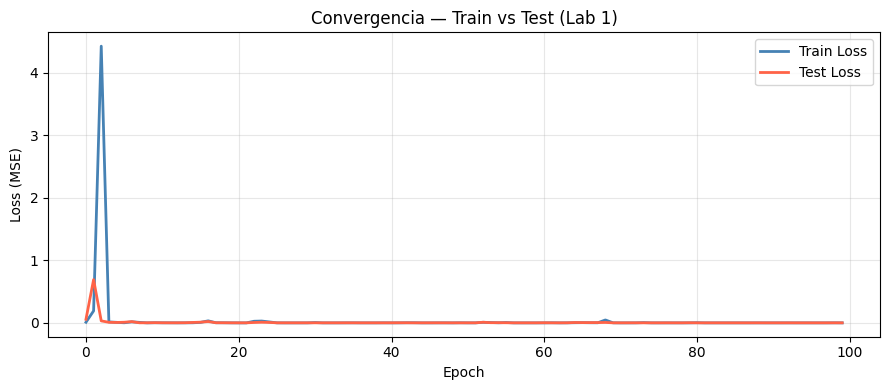

Train Loss final : 0.0002
Test  Loss final : 0.0010


In [ ]:
# Grafica: Train Loss vs Test Loss por epoch
pyplot.figure(figsize=(9, 4))
pyplot.plot(train_losses,       color='steelblue', lw=2, label='Train Loss')
pyplot.plot(test_losses_epoch,  color='tomato',    lw=2, label='Test Loss')
pyplot.xlabel('Epoch')
pyplot.ylabel('Loss (MSE)')
pyplot.title('Convergencia — Train vs Test (Lab 1)')
pyplot.legend()
pyplot.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

print(f'Train Loss final : {train_losses[-1]:.4f}')
print(f'Test  Loss final : {test_losses_epoch[-1]:.4f}')


In [ ]:
# Cargar modelo guardado
model.load_state_dict(torch.load(PATH))
model.eval()
print('Modelo cargado correctamente ✅')


Modelo cargado correctamente ✅


# PASO 8: Predicciones individuales sobre datos reales del conjunto de PRUEBA
Se toman 5 estudiantes del test y se compara prediccion vs valor real

In [ ]:

num_muestras = 5

print('\n═══════════════════════════════════════════════════════')
print('       PREDICCION vs REAL — DATOS DE TEST              ')
print('═══════════════════════════════════════════════════════')
print(f"{'Estudiante':<12} {'Prediccion':>12} {'Real':>8} {'Error abs':>10}")
print('-' * 48)

model.eval()
with torch.no_grad():
    for i in range(num_muestras):
        x_sample = X_test_tensor[i].unsqueeze(0)   # shape (1, 15)
        y_real   = y_test_tensor[i].item()
        pred     = model(x_sample).squeeze().item()
        error    = abs(pred - y_real)
        print(f'{i+1:<12} {pred:>12.2f} {y_real:>8.0f} {error:>10.2f}')

print('═══════════════════════════════════════════════════════')



═══════════════════════════════════════════════════════
       PREDICCION vs REAL — DATOS DE TEST              
═══════════════════════════════════════════════════════
Estudiante     Prediccion     Real  Error abs
------------------------------------------------
1                   35.44       35       0.06
2                   42.65       43       0.02
3                   69.66       70       0.07
4                   54.95       55       0.08
5                   57.94       58       0.11
═══════════════════════════════════════════════════════


# Laboratorio 3: Clasificacion Binaria de Supervivencia (PyTorch)
**NOMBRE:** Yulitza Alcibia Miranda  
**GRUPO:** 2  
**LINK:** https://drive.google.com/file/d/18XKh1Z6gavTFjNA5Gw5bwzGlNXqDHNM9/view?usp=sharing

**Dataset:** Patient Survival Prediction

## Descripcion del Dataset
El dataset contiene informacion clinica de **91,713 pacientes** ingresados
en UCI, con variables numericas de signos vitales, laboratorio y demografia.

## Variable Objetivo
Se predice `hospital_death`:
- `1` = fallece
- `0` = sobrevive

## Enfoque implementado en este cuadernillo
1. Limpieza y normalizacion de datos
2. Balanceo de clases con `SMOTE`
3. Entrenamiento de una red neuronal binaria con `BCELoss`
4. Evaluacion con `loss` y `accuracy` en conjunto de prueba



In [ ]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline
import pandas as pd
#funcion de la libreria que nos ayuda a dividir
from sklearn.model_selection import train_test_split
from scipy import optimize

In [ ]:
#  montar (conectar) Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## PASO 1:CARGAR DATOS DEL DATASET

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/IA_sis420/LABORATORIOS/DATASET/Patient _Survival.csv')
print(f"Forma del dataset: {df.shape}")
print(f"\nColumna objetivo:")
print(df.iloc[:, -1].value_counts())

Forma del dataset: (91713, 85)

Columna objetivo:
hospital_death
0    83798
1     7915
Name: count, dtype: int64


##PASO 2: Preprocesamiento de Datos

Antes de entrenar el modelo se realizan los siguientes pasos:


Limpieza y Separación de Datos

Se separa la variable objetivo `hospital_death` (y) de las características
numéricas (X), se eliminan columnas completamente vacías y se reemplazan
los valores nulos por la media de cada columna.

In [ ]:
# Separar caracteristicas (X) y etiqueta (y)
y = df['hospital_death'].values
X = df.select_dtypes(include=[np.number]).drop(
    columns=['hospital_death',
             'encounter_id',
             'patient_id',
             'hospital_id']
).values

print(f"Caracteristicas : {X.shape[1]}")
print(f"Ejemplares      : {X.shape[0]}")
print(f"Clases -> 0: {(y==0).sum()} | 1: {(y==1).sum()}")

# Eliminar columnas que tienen TODOS los valores nulos
cols_todas_nulas = np.where(np.all(np.isnan(X), axis=0))[0]
print(f"Columnas con todos nulos: {len(cols_todas_nulas)}")
X = np.delete(X, cols_todas_nulas, axis=1)
print(f"Columnas restantes: {X.shape[1]}")

# Ahora reemplazar nulos por la media de cada columna
col_means = np.nanmean(X, axis=0)
inds = np.where(np.isnan(X))
X[inds] = np.take(col_means, inds[1])

print(f"Valores nulos restantes: {np.isnan(X).sum()}")
print(f"X shape final: {X.shape}")

Caracteristicas : 74
Ejemplares      : 91713
Clases -> 0: 83798 | 1: 7915
Columnas con todos nulos: 1
Columnas restantes: 73
Valores nulos restantes: 0
X shape final: (91713, 73)


In [ ]:
y = df['hospital_death'].values

columnas_categoricas = [
    'apache_2_bodysystem',
    'apache_3j_bodysystem',
    'icu_type',
    'icu_admit_source',
    'gender'
]

# Aplicar ONE-HOT ENCODING
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

# Seleccionar solo numéricas (ahora incluye las nuevas columnas binarias)
X_df = df_encoded.select_dtypes(include=[np.number]).drop(
    columns=[
        'hospital_death',
        'encounter_id',
        'patient_id',
        'hospital_id'
    ]
)

X = X_df.values

print(f"Caracteristicas : {X.shape[1]}")
print(f"Ejemplares      : {X.shape[0]}")
print(f"Clases -> 0: {(y==0).sum()} | 1: {(y==1).sum()}")

# Eliminar columnas totalmente nulas
cols_todas_nulas = np.where(np.all(np.isnan(X), axis=0))[0]
print(f"Columnas con todos nulos: {len(cols_todas_nulas)}")

X = np.delete(X, cols_todas_nulas, axis=1)

print(f"Columnas restantes: {X.shape[1]}")

# Rellenar nulos con la media
col_means = np.nanmean(X, axis=0)
inds = np.where(np.isnan(X))
X[inds] = np.take(col_means, inds[1])

print(f"Valores nulos restantes: {np.isnan(X).sum()}")
print(f"X shape final: {X.shape}")

Caracteristicas : 74
Ejemplares      : 91713
Clases -> 0: 83798 | 1: 7915
Columnas con todos nulos: 1
Columnas restantes: 73
Valores nulos restantes: 0
X shape final: (91713, 73)


### Normalización y División de Datos

Se sigue el orden correcto: **primero dividir, luego normalizar**.
Los parámetros `mu` y `sigma` se calculan solo con el conjunto de
entrenamiento y se aplican al de prueba para evitar *data leakage*.
Nota: `sigma[sigma == 0] = 1` evita divisiones por cero en columnas constantes.


In [ ]:
idx_clase_0 = np.where(y == 0)[0]
idx_clase_1 = np.where(y == 1)[0]
n_por_clase = len(idx_clase_1)   # 7,915

np.random.seed(42)
idx_0_muestra = np.random.choice(idx_clase_0, n_por_clase, replace=False)
idx_final = np.concatenate([idx_0_muestra, idx_clase_1])
np.random.shuffle(idx_final)

X_bal = X[idx_final]    # ← X sin normalizar todavía
y_bal = y[idx_final]

print(f"Total: {len(X_bal)}")
print(f"Clase 0: {(y_bal==0).sum()}")
print(f"Clase 1: {(y_bal==1).sum()}")

print(f"\nDataset balanceado REAL:")
print(f"Total     : {len(X_bal)}")
print(f"Sobrevive : {(y_bal==0).sum()}")
print(f"Fallece   : {(y_bal==1).sum()}")


Total: 15830
Clase 0: 7915
Clase 1: 7915

Dataset balanceado REAL:
Total     : 15830
Sobrevive : 7915
Fallece   : 7915


In [ ]:
from sklearn.model_selection import train_test_split

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_bal, y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal
)

print(f"Train: {X_train_np.shape}")
print(f"Test:  {X_test_np.shape}")


Train: (12664, 73)
Test:  (3166, 73)


In [ ]:
def featureNormalize(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# mu y sigma calculados SOLO con train
X_train_norm, mu, sigma = featureNormalize(X_train_np)

# aplicar esos mismos parámetros al test
X_test_norm = (X_test_np - mu) / sigma

print(f"Normalización aplicada ✅")
print(f"Train normalizado: {X_train_norm.shape}")
print(f"Test  normalizado: {X_test_norm.shape}")

Normalización aplicada ✅
Train normalizado: (12664, 73)
Test  normalizado: (3166, 73)


In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando: {device}')

X_train = torch.from_numpy(X_train_norm).float().to(device)
y_train = torch.from_numpy(y_train_np).float().to(device)
X_test  = torch.from_numpy(X_test_norm).float().to(device)
y_test  = torch.from_numpy(y_test_np).float().to(device)

print(f'Train: {X_train.shape}')
print(f'Test:  {X_test.shape}')
print(f'Train clase 0: {(y_train_np==0).sum()}')
print(f'Train clase 1: {(y_train_np==1).sum()}')
print(f'Test  clase 0: {(y_test_np==0).sum()}')
print(f'Test  clase 1: {(y_test_np==1).sum()}')


Usando: cpu
Train: torch.Size([12664, 73])
Test:  torch.Size([3166, 73])
Train clase 0: 6332
Train clase 1: 6332
Test  clase 0: 1583
Test  clase 1: 1583


##PASO 3: Crear el Dataset

In [ ]:
# PASO 3: Dataset personalizado

class PacienteDataset(torch.utils.data.Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)        # cuántos pacientes hay

    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]   # paciente ix y si falleció


# Crear datasets
train_dataset = PacienteDataset(X_train, y_train)
test_dataset  = PacienteDataset(X_test, y_test)

print(f"Pacientes entrenamiento: {len(train_dataset)}")
print(f"Pacientes evaluación:    {len(test_dataset)}")

Pacientes entrenamiento: 12664
Pacientes evaluación:    3166


## PASO 4: Crear el DataLoader

In [ ]:

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=100,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=100,
    shuffle=False
)

print(f"Batches entrenamiento: {len(train_loader)}")
print(f"Batches evaluación:    {len(test_loader)}")

Batches entrenamiento: 127
Batches evaluación:    32


##PASO 5: DEFINICION DE LA RED NEURAL SECUENCIAL

In [ ]:
# PASO 5: Definir modelo

D_in  = 73   # características de cada paciente
H     = 128   # neuronas ocultas
D_out = 1    # salida: probabilidad de fallecer

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),   # capa 1: 76 → 64
    torch.nn.ReLU(),             # activación
    torch.nn.Linear(H, D_out),  # capa 2: 64 → 1
    torch.nn.Sigmoid()           # convierte a probabilidad ← NUEVO
).to(device)

print(model)
print(f"\nParámetros totales: {sum(p.numel() for p in model.parameters())}")

Sequential(
  (0): Linear(in_features=73, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=1, bias=True)
  (3): Sigmoid()
)

Parámetros totales: 9601


# PASO 6: Loss y Optimizador

In [ ]:
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    weight_decay=0.001
)

##PASO 7: Entrenamiento

### Explicacion del entrenamiento binario
En esta etapa el modelo aprende a distinguir entre `fallece` y `sobrevive`.
`BCELoss` penaliza probabilidades incorrectas y `SGD` actualiza los pesos.
Tambien se mide `accuracy` por epoch para monitorear estabilidad del aprendizaje.

In [ ]:
# PASO 7: Entrenamiento
epochs   = 100
log_each = 10
train_losses = []
train_accs   = []
test_losses_epoch  = []   # loss en test al final de cada epoch
test_accs_epoch    = []   # accuracy en test al final de cada epoch
best_loss    = float('inf')
PATH = '/content/drive/MyDrive/IA_sis420/LABORATORIOS/modelo_pacientes.pt'

for e in range(1, epochs + 1):

    # ── Fase entrenamiento ──
    model.train()
    batch_losses = []
    batch_accs   = []
    for x_b, y_b in train_loader:
        optimizer.zero_grad()
        #forward
        y_pred = model(x_b).squeeze()
        loss   = criterion(y_pred, y_b)
        batch_losses.append(loss.item())
        y_clase = (y_pred >= 0.5).float()
        batch_accs.append((y_clase == y_b).float().mean().item() * 100)
        loss.backward()
        optimizer.step()

    epoch_loss = np.mean(batch_losses)
    epoch_acc  = np.mean(batch_accs)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    # ── Fase evaluacion en test ──
    model.eval()
    with torch.no_grad():
        t_losses, t_accs = [], []
        for x_b, y_b in test_loader:
            y_pred  = model(x_b).squeeze()
            t_losses.append(criterion(y_pred, y_b).item())
            y_clase = (y_pred >= 0.5).float()
            t_accs.append((y_clase == y_b).float().mean().item() * 100)
        test_loss_e = np.mean(t_losses)
        test_acc_e  = np.mean(t_accs)
        test_losses_epoch.append(test_loss_e)
        test_accs_epoch.append(test_acc_e)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), PATH)
        print(f'✅ Epoch {e}: guardado (Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%)')

    if not e % log_each:
        print(f'Epoch {e}/{epochs}  TrainLoss: {epoch_loss:.4f}  TestLoss: {test_loss_e:.4f}  TestAcc: {test_acc_e:.2f}%')

✅ Epoch 1: guardado (Train Loss: 0.6405 | Train Acc: 64.77%)
✅ Epoch 2: guardado (Train Loss: 0.5582 | Train Acc: 74.31%)
✅ Epoch 3: guardado (Train Loss: 0.5180 | Train Acc: 75.67%)
✅ Epoch 4: guardado (Train Loss: 0.4960 | Train Acc: 76.51%)
✅ Epoch 5: guardado (Train Loss: 0.4832 | Train Acc: 77.16%)
✅ Epoch 6: guardado (Train Loss: 0.4748 | Train Acc: 77.54%)
✅ Epoch 7: guardado (Train Loss: 0.4690 | Train Acc: 77.80%)
✅ Epoch 8: guardado (Train Loss: 0.4644 | Train Acc: 77.94%)
✅ Epoch 9: guardado (Train Loss: 0.4613 | Train Acc: 78.24%)
✅ Epoch 10: guardado (Train Loss: 0.4585 | Train Acc: 78.32%)
Epoch 10/100  TrainLoss: 0.4585  TestLoss: 0.4645  TestAcc: 78.45%
✅ Epoch 11: guardado (Train Loss: 0.4564 | Train Acc: 78.38%)
✅ Epoch 12: guardado (Train Loss: 0.4536 | Train Acc: 78.65%)
✅ Epoch 13: guardado (Train Loss: 0.4521 | Train Acc: 78.80%)
✅ Epoch 14: guardado (Train Loss: 0.4506 | Train Acc: 78.88%)
✅ Epoch 15: guardado (Train Loss: 0.4496 | Train Acc: 79.00%)
✅ Epoch 16: 

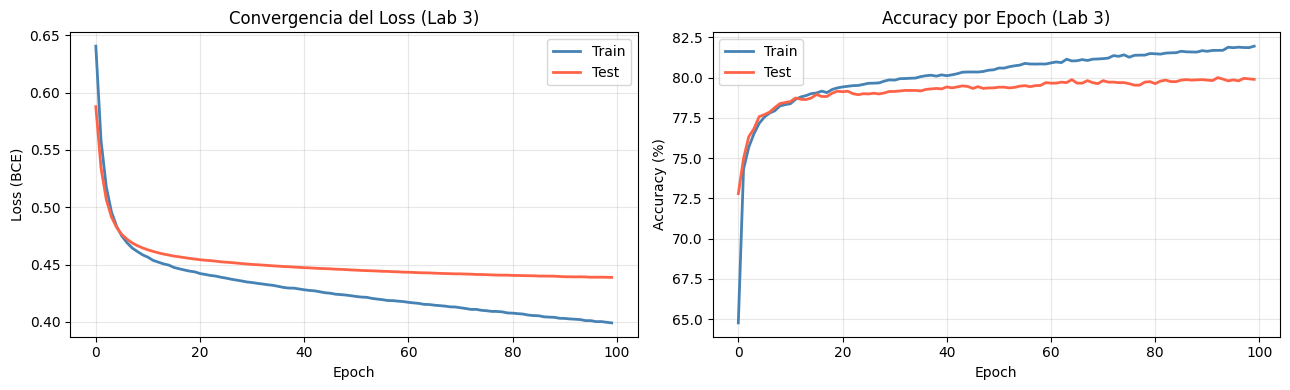

Train Loss final: 0.3992  |  Test Loss final: 0.4388
Train Acc final:  81.95%   |  Test Acc final:  79.89%


In [ ]:
# Graficas: Train vs Test — Loss y Accuracy
fig, axes = pyplot.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses,      color='steelblue', lw=2, label='Train')
axes[0].plot(test_losses_epoch, color='tomato',    lw=2, label='Test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Convergencia del Loss (Lab 3)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs,       color='steelblue', lw=2, label='Train')
axes[1].plot(test_accs_epoch,  color='tomato',    lw=2, label='Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy por Epoch (Lab 3)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

print(f'Train Loss final: {train_losses[-1]:.4f}  |  Test Loss final: {test_losses_epoch[-1]:.4f}')
print(f'Train Acc final:  {train_accs[-1]:.2f}%   |  Test Acc final:  {test_accs_epoch[-1]:.2f}%')


# PASO 8: Predicciones individuales — 3 que fallecen y 3 que sobreviven del TEST

In [ ]:

idx_fallece   = np.where(y_test_np == 1)[0][:3]
idx_sobrevive = np.where(y_test_np == 0)[0][:3]
indices = np.concatenate([idx_fallece, idx_sobrevive])

print('═══════════════════════════════════════════════════════')
print('           PREDICCION PACIENTES DEL TEST               ')
print('═══════════════════════════════════════════════════════')
print(f"{'Paciente':<12} {'P(Fallece)':<15} {'Prediccion':<12} {'Real':<8} {'Estado'}")
print('-' * 57)

model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):
        paciente = X_test[idx].unsqueeze(0)
        prob  = model(paciente).squeeze().item()
        pred  = 1 if prob >= 0.5 else 0
        real  = int(y_test[idx].item())
        estado = '✅ Correcto' if pred == real else '❌ Incorrecto'
        print(f'{i+1:<12} {prob:<15.4f} {pred:<12} {real:<8} {estado}')

print('═══════════════════════════════════════════════════════')


═══════════════════════════════════════════════════════
           PREDICCION PACIENTES DEL TEST               
═══════════════════════════════════════════════════════
Paciente     P(Fallece)      Prediccion   Real     Estado
---------------------------------------------------------
1            0.7223          1            1        ✅ Correcto
2            0.4991          0            1        ❌ Incorrecto
3            0.8448          1            1        ✅ Correcto
4            0.2876          0            0        ✅ Correcto
5            0.0802          0            0        ✅ Correcto
6            0.0385          0            0        ✅ Correcto
═══════════════════════════════════════════════════════


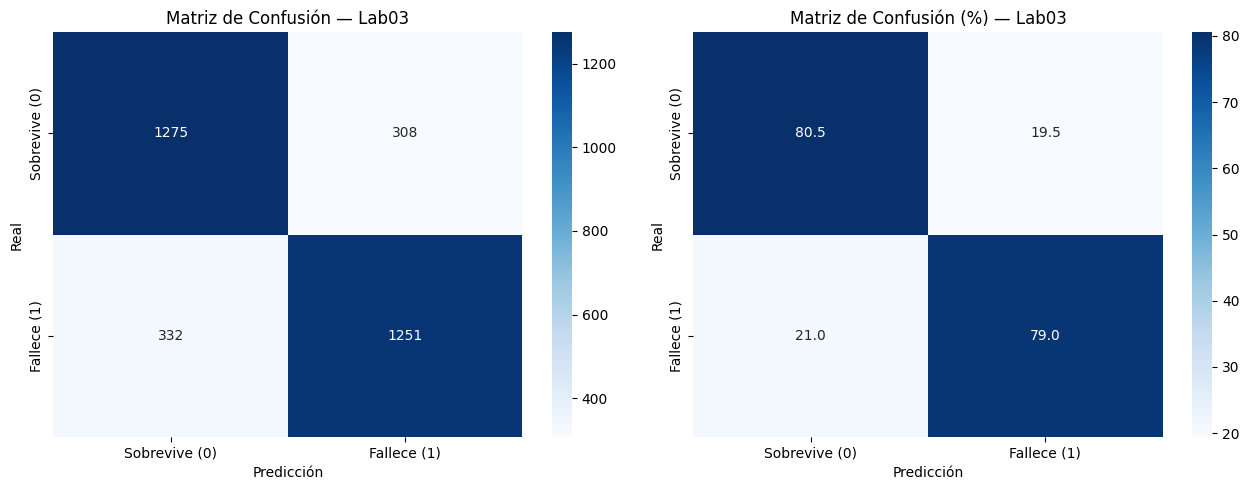

              precision    recall  f1-score   support

   Sobrevive       0.79      0.81      0.80      1583
     Fallece       0.80      0.79      0.80      1583

    accuracy                           0.80      3166
   macro avg       0.80      0.80      0.80      3166
weighted avg       0.80      0.80      0.80      3166



In [ ]:
# MATRIZ DE CONFUSIÓN — Lab03
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
y_preds = []
y_reals = []

with torch.no_grad():
    for x_b, y_b in test_loader:
        y_pred  = model(x_b).squeeze()
        y_clase = (y_pred >= 0.5).float()
        y_preds.extend(y_clase.cpu().numpy())
        y_reals.extend(y_b.cpu().numpy())

y_preds = np.array(y_preds).astype(int)
y_reals = np.array(y_reals).astype(int)

# Calcular matriz
cm = confusion_matrix(y_reals, y_preds)

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Sobrevive (0)', 'Fallece (1)'],
    yticklabels=['Sobrevive (0)', 'Fallece (1)'],
    ax=axes[0]
)
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusión — Lab03')

# Matriz normalizada (en porcentaje)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=['Sobrevive (0)', 'Fallece (1)'],
    yticklabels=['Sobrevive (0)', 'Fallece (1)'],
    ax=axes[1]
)
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión (%) — Lab03')

plt.tight_layout()
plt.show()

# Reporte
print(classification_report(
    y_reals, y_preds,
    target_names=['Sobrevive', 'Fallece']
))

In [ ]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load(PATH))
model.eval()
print("✅ Mejor modelo cargado correctamente")


✅ Mejor modelo cargado correctamente


# Laboratorio 4 - Clasificacion Multiclase de Gestos (PyTorch)

**Nombre:** Alcibia Miranda Yulitza

**Grupo:** 2

## Dataset Multimodal: Gestos de Mano (Hand Gestures)
URL: https://drive.google.com/drive/folders/1wuD5wpJbz3yYgZLJAz8WrMMGLrhbIebu?usp=sharing

---

### Descripcion del Dataset
El dataset contiene imagenes en escala de grises de gestos de mano.
Cada imagen se redimensiona a **20x20 pixeles**, generando **400 features** por ejemplo.

**Numero de features (n):** 400  
**Numero de ejemplos (m):** ~7,000  
**Numero de clases (K):** 7

### Clases
- `0` - fist
- `1` - five
- `2` - okay
- `3` - peace
- `4` - rad
- `5` - straight
- `6` - thumbs

### Estrategia del Modelo
Se entrena una **red neuronal multiclase** con PyTorch y `CrossEntropyLoss`.
La prediccion final se obtiene con `argmax` sobre las 7 salidas del modelo.

$$\hat{y} = \arg\max_k f_\theta(x)_k$$

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
from scipy import optimize
import cv2
import os
import glob
from matplotlib import pyplot
%matplotlib inline
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando: {device}")
print('Librerías importadas correctamente.')

Usando: cpu
Librerías importadas correctamente.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive montado correctamente.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado correctamente.


##PASO 1: Cargar imágenes

In [ ]:
clases = ['fist', 'five', 'okay', 'peace', 'rad', 'straight', 'thumbs']
num_labels = len(clases)
input_layer_size = 20 * 20
ruta_base = '/content/drive/MyDrive/IA_sis420/LABORATORIOS/DATASET/data/'

def cargar_datos(carpeta):

    X_list = []
    y_list = []

    for etiqueta, clase in enumerate(clases):
        ruta = ruta_base + carpeta + '/' + clase + '/*.png'
        imagenes = glob.glob(ruta)

        for imagen_path in imagenes:
            imagen = cv2.imread(imagen_path, cv2.IMREAD_GRAYSCALE)
            imagen = cv2.resize(imagen, (20, 20))   # 20x20
            imagen = imagen.flatten() / 255.0        # normalizar a [0, 1]
            X_list.append(imagen)
            y_list.append(etiqueta)

    return np.array(X_list), np.array(y_list)

X_raw, y_raw = cargar_datos('train')

m_total = y_raw.size
print(f"Total imágenes cargadas: {X_raw.shape[0]}")
print(f"Features por imagen:     {X_raw.shape[1]}  (= 20x20)")
print(f"Clases encontradas:      {np.unique(y_raw)}  ({num_labels} clases)")

Total imágenes cargadas: 6999
Features por imagen:     400  (= 20x20)
Clases encontradas:      [0 1 2 3 4 5 6]  (7 clases)


##PASO 2: Dividir train/test


In [ ]:
from sklearn.model_selection import train_test_split

X, X_test, y, y_test = train_test_split(
    X_raw, y_raw,
    test_size=0.20,
    random_state=42,
    stratify=y_raw    # garantiza misma proporción de clases
)

print(f"Entrenamiento: {X.shape[0]} imágenes")
print(f"Prueba:        {X_test.shape[0]} imágenes")

Entrenamiento: 5599 imágenes
Prueba:        1400 imágenes


##PASO 3: Convertir a tensores

In [ ]:
# Convertir a tensores
X_tensor      = torch.from_numpy(X).float().to(device)
y_tensor      = torch.from_numpy(y).long().to(device)
X_test_tensor = torch.from_numpy(X_test).float().to(device)
y_test_tensor = torch.from_numpy(y_test).long().to(device)

print(f"X train: {X_tensor.shape}")       # → (5600, 400)
print(f"y train: {y_tensor.shape}")       # → (5600,)
print(f"X test:  {X_test_tensor.shape}")  # → (1400, 400)

X train: torch.Size([5599, 400])
y train: torch.Size([5599])
X test:  torch.Size([1400, 400])


##PASO 4: Crear Dataset

In [ ]:

class GestosDataset(torch.utils.data.Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]


# Crear datasets
train_dataset = GestosDataset(X_tensor, y_tensor)
test_dataset  = GestosDataset(X_test_tensor, y_test_tensor)

print(f"Imágenes entrenamiento: {len(train_dataset)}")
print(f"Imágenes evaluación:    {len(test_dataset)}")


Imágenes entrenamiento: 5599
Imágenes evaluación:    1400


##PASO 5: Crear DataLoader

In [ ]:

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print(f"Batches entrenamiento: {len(train_loader)}")
print(f"Batches evaluación:    {len(test_loader)}")


Batches entrenamiento: 88
Batches evaluación:    22


##PASO 6: DEFINICION DE LA RED NEURAL SECUENCIAL

In [ ]:
D_in  = 400   # features: 20×20 píxeles
H     = 128   # neuronas ocultas
D_out = 7     # una salida por cada gesto

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),   # capa 1: 400 → 128
    torch.nn.ReLU(),             # activación
    torch.nn.Linear(H, D_out),  # capa 2: 128 → 7
).to(device)

print(model)
print(f"\nParámetros totales: {sum(p.numel() for p in model.parameters())}")


Sequential(
  (0): Linear(in_features=400, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=7, bias=True)
)

Parámetros totales: 52231


## PASO 7: Loss y Optimizador


### Loss y Optimizador

`CrossEntropyLoss` es la función de pérdida estándar para clasificación multiclase.
Internamente aplica Softmax sobre las 7 salidas del modelo y calcula la entropía cruzada
contra la clase real. Por eso la última capa del modelo **no** lleva activación Softmax.

`SGD` con `weight_decay=0.001` agrega regularización L2 para penalizar pesos grandes
y reducir el sobreajuste, equivalente al parámetro `lambda_` de laboratorios anteriores.


In [ ]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    weight_decay=0.001
)


##PASO 8: Entrenamiento

### Explicacion del entrenamiento multiclase
El modelo produce 7 puntajes por imagen (uno por gesto).
`CrossEntropyLoss` compara esos puntajes con la clase real y optimiza pesos.
La prediccion final se obtiene con `argmax` (clase de mayor puntaje).

In [ ]:
# PASO 9: Entrenamiento
epochs   = 100
log_each = 10
train_losses = []
train_accs   = []
test_losses_epoch = []
test_accs_epoch   = []
best_loss    = float('inf')
PATH = '/content/drive/MyDrive/IA_sis420/LABORATORIOS/modelo_gestos.pt'

for e in range(1, epochs + 1):

    # ── Fase entrenamiento ──
    model.train()
    batch_losses = []
    batch_accs   = []
    for x_b, y_b in train_loader:
        optimizer.zero_grad()
        y_pred = model(x_b)
        loss   = criterion(y_pred, y_b)
        batch_losses.append(loss.item())
        y_clase = torch.argmax(y_pred, dim=1)
        batch_accs.append((y_clase == y_b).float().mean().item() * 100)
        loss.backward()
        optimizer.step()

    epoch_loss = np.mean(batch_losses)
    epoch_acc  = np.mean(batch_accs)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    # ── Fase evaluacion en test ──
    model.eval()
    with torch.no_grad():
        t_losses, t_accs = [], []
        for x_b, y_b in test_loader:
            y_pred  = model(x_b)
            t_losses.append(criterion(y_pred, y_b).item())
            y_clase = torch.argmax(y_pred, dim=1)
            t_accs.append((y_clase == y_b).float().mean().item() * 100)
        test_loss_e = np.mean(t_losses)
        test_acc_e  = np.mean(t_accs)
        test_losses_epoch.append(test_loss_e)
        test_accs_epoch.append(test_acc_e)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), PATH)
        print(f'✅ Epoch {e}: guardado (Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%)')

    if not e % log_each:
        print(f'Epoch {e}/{epochs}  TrainLoss: {epoch_loss:.4f}  TestLoss: {test_loss_e:.4f}  TestAcc: {test_acc_e:.2f}%')


✅ Epoch 1: guardado (Train Loss: 1.8542 | Train Acc: 34.23%)
✅ Epoch 2: guardado (Train Loss: 1.6761 | Train Acc: 48.20%)
✅ Epoch 3: guardado (Train Loss: 1.5089 | Train Acc: 53.64%)
✅ Epoch 4: guardado (Train Loss: 1.3717 | Train Acc: 56.48%)
✅ Epoch 5: guardado (Train Loss: 1.2604 | Train Acc: 59.50%)
✅ Epoch 6: guardado (Train Loss: 1.1665 | Train Acc: 62.66%)
✅ Epoch 7: guardado (Train Loss: 1.0832 | Train Acc: 66.13%)
✅ Epoch 8: guardado (Train Loss: 1.0093 | Train Acc: 69.18%)
✅ Epoch 9: guardado (Train Loss: 0.9429 | Train Acc: 72.25%)
✅ Epoch 10: guardado (Train Loss: 0.8819 | Train Acc: 73.84%)
Epoch 10/100  TrainLoss: 0.8819  TestLoss: 0.8400  TestAcc: 75.95%
✅ Epoch 11: guardado (Train Loss: 0.8274 | Train Acc: 76.36%)
✅ Epoch 12: guardado (Train Loss: 0.7787 | Train Acc: 77.75%)
✅ Epoch 13: guardado (Train Loss: 0.7349 | Train Acc: 79.54%)
✅ Epoch 14: guardado (Train Loss: 0.6934 | Train Acc: 80.96%)
✅ Epoch 15: guardado (Train Loss: 0.6585 | Train Acc: 82.07%)
✅ Epoch 16: 

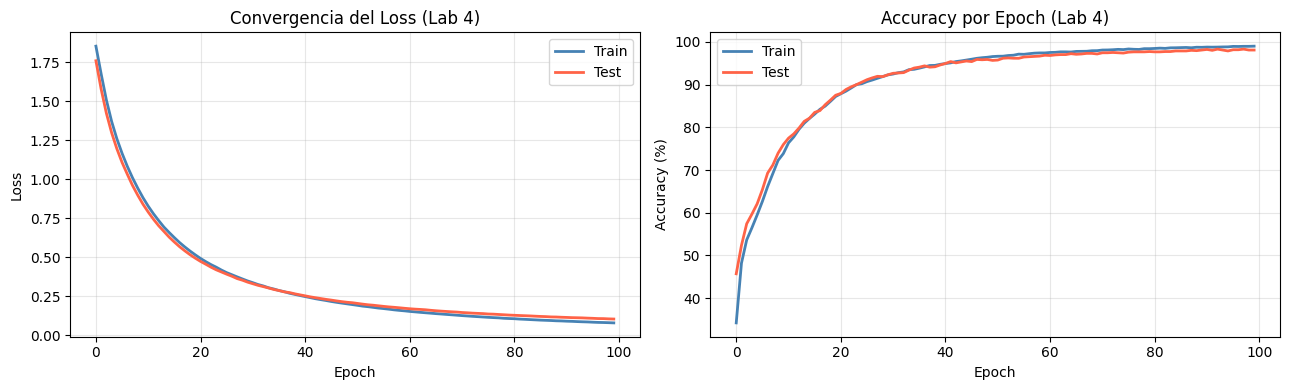

Train Loss final: 0.0787  |  Test Loss final: 0.1034
Train Acc final:  98.99%   |  Test Acc final:  98.08%


In [ ]:
# Graficas: Train vs Test — Loss y Accuracy
fig, axes = pyplot.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses,      color='steelblue', lw=2, label='Train')
axes[0].plot(test_losses_epoch, color='tomato',    lw=2, label='Test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Convergencia del Loss (Lab 4)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs,       color='steelblue', lw=2, label='Train')
axes[1].plot(test_accs_epoch,  color='tomato',    lw=2, label='Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy por Epoch (Lab 4)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

print(f'Train Loss final: {train_losses[-1]:.4f}  |  Test Loss final: {test_losses_epoch[-1]:.4f}')
print(f'Train Acc final:  {train_accs[-1]:.2f}%   |  Test Acc final:  {test_accs_epoch[-1]:.2f}%')


##PASO 9: Evaluar y Predecir

In [ ]:
# PASO 9A: Predecir imágenes del test

# Agarrar 7 imágenes, una de cada clase
indices = []
for clase in range(7):
    idx = np.where(y_test == clase)[0][0]
    indices.append(idx)

print("═══════════════════════════════════════════════════════")
print("           PREDICCIÓN DE GESTOS NUEVOS                ")
print("═══════════════════════════════════════════════════════")
print(f"{'Imagen':<10} {'Predicción':<15} {'Real':<15} {'Estado'}")
print("-" * 55)

model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):

        # Agarrar imagen
        imagen = X_test_tensor[idx].unsqueeze(0)   # (1, 400)

        # Predecir
        y_pred  = model(imagen)
        pred    = torch.argmax(y_pred, dim=1).item()
        real    = y_test[idx]
        estado  = "✅ Correcto" if pred == real else "❌ Incorrecto"

        print(f"{i+1:<10} {clases[pred]:<15} {clases[real]:<15} {estado}")

print("═══════════════════════════════════════════════════════")

═══════════════════════════════════════════════════════
           PREDICCIÓN DE GESTOS NUEVOS                
═══════════════════════════════════════════════════════
Imagen     Predicción      Real            Estado
-------------------------------------------------------
1          fist            fist            ✅ Correcto
2          five            five            ✅ Correcto
3          okay            okay            ✅ Correcto
4          peace           peace           ✅ Correcto
5          rad             rad             ✅ Correcto
6          straight        straight        ✅ Correcto
7          thumbs          thumbs          ✅ Correcto
═══════════════════════════════════════════════════════


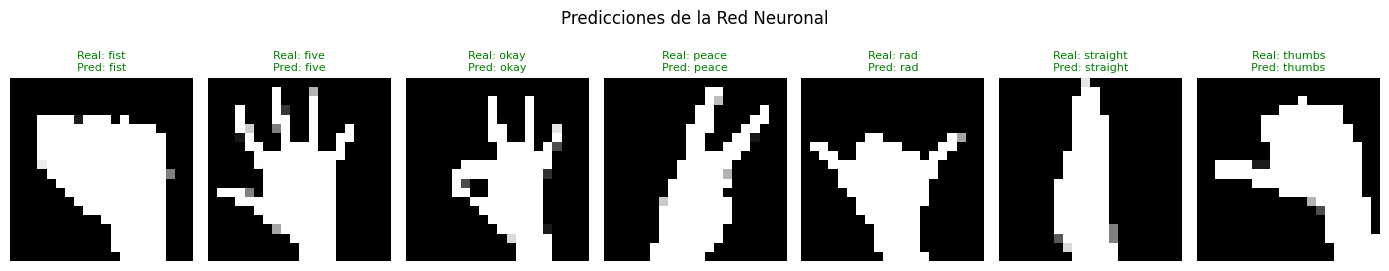

In [ ]:
# PASO 9B: Mostrar imágenes con predicciones

fig, axes = pyplot.subplots(1, 7, figsize=(14, 3))

model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):

        imagen        = X_test_tensor[idx].unsqueeze(0)
        y_pred        = model(imagen)
        pred          = torch.argmax(y_pred, dim=1).item()
        real          = y_test[idx]

        # Mostrar imagen
        axes[i].imshow(
            X_test[idx].reshape(20, 20),
            cmap='gray'
        )
        color = 'green' if pred == real else 'red'
        axes[i].set_title(
            f"Real: {clases[real]}\nPred: {clases[pred]}",
            color=color,
            fontsize=8
        )
        axes[i].axis('off')

pyplot.suptitle('Predicciones de la Red Neuronal', fontsize=12)
pyplot.tight_layout()
pyplot.show()

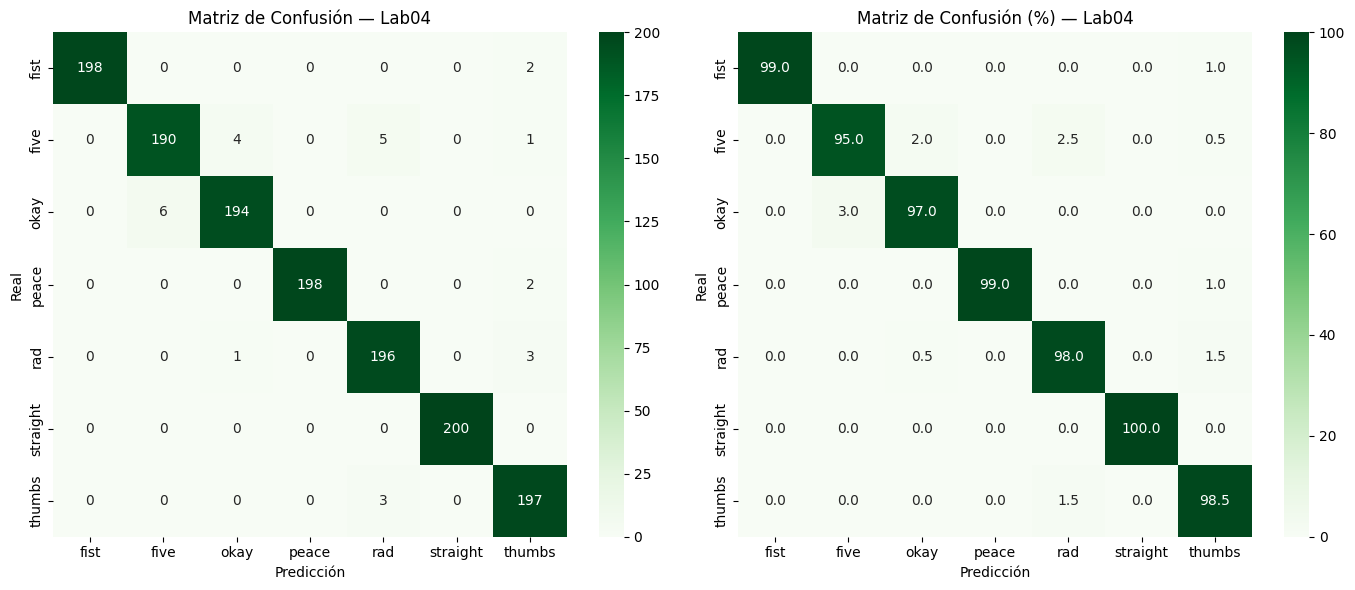

              precision    recall  f1-score   support

        fist       1.00      0.99      0.99       200
        five       0.97      0.95      0.96       200
        okay       0.97      0.97      0.97       200
       peace       1.00      0.99      0.99       200
         rad       0.96      0.98      0.97       200
    straight       1.00      1.00      1.00       200
      thumbs       0.96      0.98      0.97       200

    accuracy                           0.98      1400
   macro avg       0.98      0.98      0.98      1400
weighted avg       0.98      0.98      0.98      1400



In [ ]:
# MATRIZ DE CONFUSIÓN — Lab04
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
y_preds = []
y_reals = []

with torch.no_grad():
    for x_b, y_b in test_loader:
        y_pred  = model(x_b)
        y_clase = torch.argmax(y_pred, dim=1)
        y_preds.extend(y_clase.cpu().numpy())
        y_reals.extend(y_b.cpu().numpy())

y_preds = np.array(y_preds)
y_reals = np.array(y_reals)

# Calcular matriz
cm = confusion_matrix(y_reals, y_preds)

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz de confusión absoluta
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=clases,
    yticklabels=clases,
    ax=axes[0]
)
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusión — Lab04')

# Matriz normalizada (en porcentaje)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.1f',
    cmap='Greens',
    xticklabels=clases,
    yticklabels=clases,
    ax=axes[1]
)
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión (%) — Lab04')

plt.tight_layout()
plt.show()

# Reporte
print(classification_report(y_reals, y_preds, target_names=clases))

In [ ]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load(PATH))
model.eval()
print("✅ Mejor modelo cargado correctamente")


✅ Mejor modelo cargado correctamente
